<a href="https://colab.research.google.com/github/NIHLA098/Market-Adaptive-Intelligent-Dynamic-Pricing-System/blob/main/Market_Adaptive_Intelligent_Dynamic_Pricing_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 **Market Adaptive Intelligent Dynamic Pricing System**

A full-fledged end-to-end machine learning project that predicts optimal product prices using demand, sales, and time-based features. Designed to showcase advanced EDA, dynamic pricing logic, and real-time prediction behavior.

 **Load and Preview the Dataset**

I'm using here the Online Retail Dataset from UCI, containing transactional data for an e-commerce store.

The Online Retail Dataset from the UCI Machine Learning Repository is a real-world transactional dataset from a UK-based e-commerce store that sells gifts and household items.

✅** Key Highlights:**

Source: UCI Machine Learning Repository

Time Range: December 1, 2023 – january 27 , 2024

Transactions: ~541,000

Customers: Mostly registered retail customers in the UK and EU

Currency: All prices are in British Pounds (GBP)



 **Import Required Libraries**

 **📘 What Each Import Is Used For:**

pandas, numpy: Handling and processing data

matplotlib, seaborn: Plotting charts and data visualizations

datetime: Extracting time-based features (hour, day, month)

sklearn: ML model building, training/testing split, performance evaluation

warnings: Ignores non-critical warnings to keep output clean

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")


**Upload the Online Real time e-commerce dataset and quick overview of it**

In [ ]:
# Upload Online Retail Dataset
df = pd.read_excel('/content/Online Retail.xlsx')

# Quick overview
print(df.shape)
df.head()


(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


**Data Cleaning and Preprocessing**

Remove nulls, invalid records, and compute useful fields like `TotalPrice`, `Hour`, `Month`, `DayOfWeek`.


In [ ]:

df = df.dropna()

df = df[df['Quantity'] > 0]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Month'] = df['InvoiceDate'].dt.month
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df = df[df['UnitPrice'] > 0]
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Month,Hour,DayOfWeek,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,8,2,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,8,2,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,8,2,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,8,2,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,8,2,20.34


**Aggregate Product-Level Features**

We now summarize the transactional data by product (StockCode) to create rich features for price prediction. These features capture:

Total sales volume (Total_Quantity)

Average unit price (Avg_Price)

Total revenue (Total_Revenue)

Number of transactions (Num_Transactions)

Most frequent time features like month, hour, and day of the week (to model seasonal pricing behavior)


In [ ]:

product_df = df.groupby('StockCode').agg({
    'Quantity': 'sum',
    'UnitPrice': 'mean',
    'TotalPrice': 'sum',
    'InvoiceNo': 'count',
    'Month': lambda x: x.mode()[0],  # Most frequent month sold
    'Hour': lambda x: x.mode()[0],
    'DayOfWeek': lambda x: x.mode()[0]
}).reset_index()

product_df.rename(columns={
    'Quantity': 'Total_Quantity',
    'UnitPrice': 'Avg_Price',
    'TotalPrice': 'Total_Revenue',
    'InvoiceNo': 'Num_Transactions'
}, inplace=True)

product_df.head()


,StockCode,Total_Quantity,Avg_Price,Total_Revenue,Num_Transactions,Month,Hour,DayOfWeek
0,10002,823,0.850000,699.55,49,1,12,3
1,10080,291,0.411905,114.41,21,11,15,0
2,10120,193,0.210000,40.53,30,11,12,4
3,10125,1226,0.782813,930.30,64,3,12,0
4,10133,2384,0.527500,1143.61,124,6,12,3


**Define the Target Variable — Optimal Price**

Total_Revenue / Total_Quantity gives average selling price

Num_Transactions * 0.1 adjusts for demand frequency, so high-demand products are priced slightly higher

In [ ]:
# Proxy: Optimal Price = Revenue per Unit adjusted for demand frequency
product_df['OptimalPrice'] = (
    product_df['Total_Revenue'] / product_df['Total_Quantity'] +
    product_df['Num_Transactions'] * 0.1
)


**Prepare Feature Matrix and Target Variable**

We now define the input features (X) and the target variable (y) for training the machine learning model.

Avg_Price: Average price of the product

Total_Quantity: Total units sold

Num_Transactions: Number of times the product was sold

Month, Hour, DayOfWeek: Time-based features to capture seasonality and behavior

Then we split the dataset into training (80%) and testing (20%) sets to evaluate performance.

In [ ]:
features = ['Avg_Price', 'Total_Quantity', 'Num_Transactions', 'Month', 'Hour', 'DayOfWeek']
target = 'OptimalPrice'

X = product_df[features]
y = product_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


**Train the Random Forest Regressor**

Here used a Random Forest Regressor, a powerful ensemble model that combines multiple decision trees to improve accuracy and reduce overfitting.

n_estimators=100:  Builds 100 trees in the forest

random_state=42:  Ensures consistent results on every run

In [ ]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

**Evaluate Model Performance**

Now, assess how well the trained model is predicting optimal prices using:

MAE (Mean Absolute Error): Average difference between actual and predicted prices

RMSE (Root Mean Squared Error): Penalizes larger errors more, making it sensitive to outliers

In [ ]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


MAE: 0.38
RMSE: 1.70


**Visualize Actual vs Predicted Optimal Prices**

To better understand how well the model performs, we plot the first 50 predictions from the test set. This comparison helps identify patterns, deviations, and the overall trend captured by the model.

✅ A close alignment between the actual and predicted lines means the model is performing well.


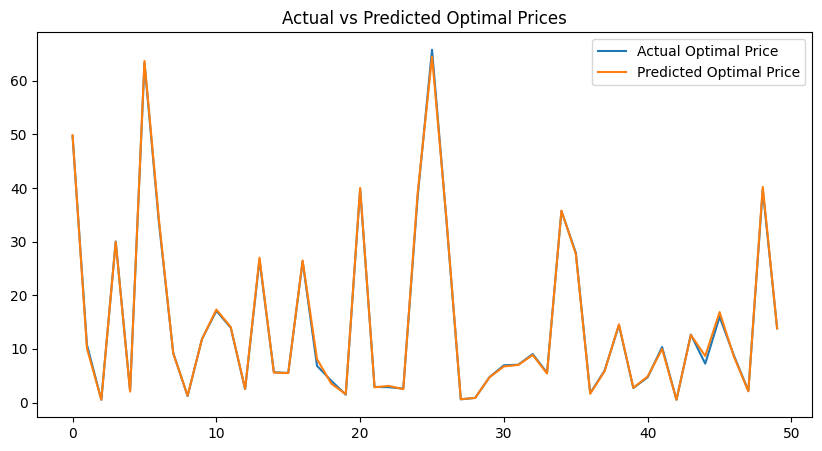

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], label='Actual Optimal Price')
plt.plot(y_pred[:50], label='Predicted Optimal Price')
plt.legend()
plt.title('Actual vs Predicted Optimal Prices')
plt.show()


**Visualize Top 10 Most Sold Products**

Understanding which products sell the most is key to prioritizing dynamic pricing strategies. This bar chart shows the top 10 products by total quantity sold.

✅ This helps identify high-demand items that are prime candidates for price optimization.


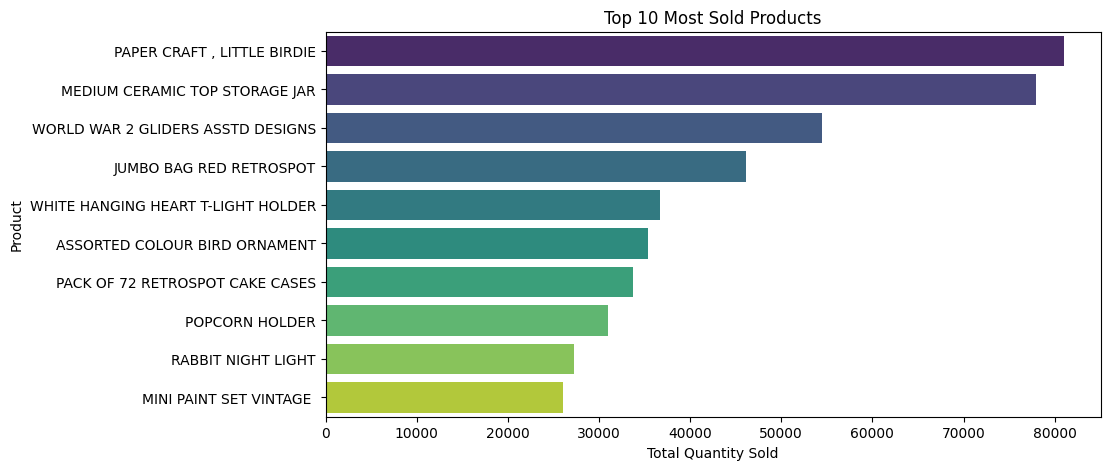

In [ ]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title('Top 10 Most Sold Products')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.show()


**Visualize Top 10 Revenue-Generating Products**

While high sales volume is important, revenue is a better indicator of a product's business impact. This chart shows the top 10 products by total revenue — ideal candidates for premium pricing strategies.

✅ This helps you identify products that contribute most to sales revenue and where pricing has a significant business impact

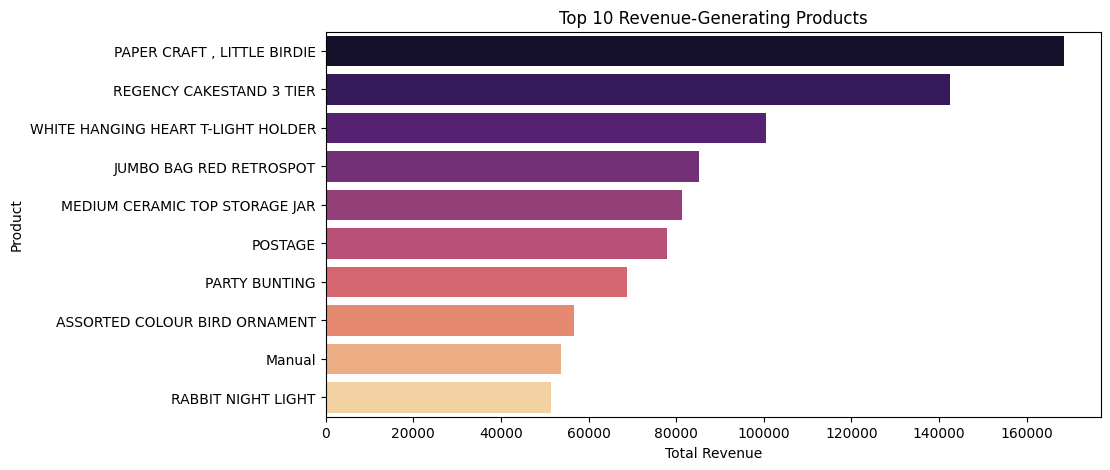

In [ ]:
top_revenue = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_revenue.values, y=top_revenue.index, palette='magma')
plt.title('Top 10 Revenue-Generating Products')
plt.xlabel('Total Revenue')
plt.ylabel('Product')
plt.show()


**Visualize Monthly Sales Trends**

Seasonality plays a key role in dynamic pricing. By analyzing monthly revenue, we can identify high-demand months where pricing strategies (like surge pricing or discounts) can be optimized.

✅ This visualization helps identify sales peaks (like holidays or year-end) and supports time-sensitive price adjustments.

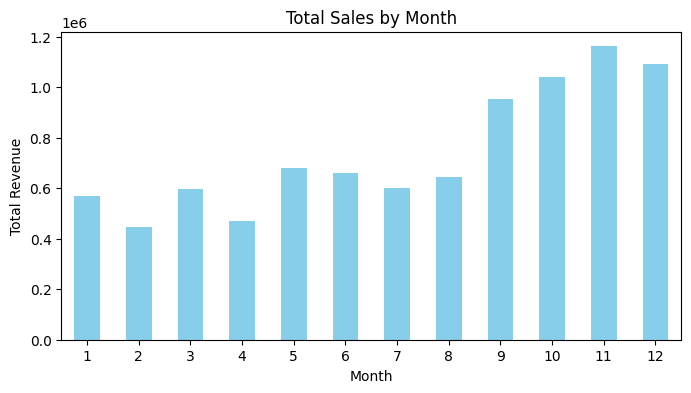

In [ ]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()
plt.figure(figsize=(8,4))
monthly_sales.plot(kind='bar', color='skyblue')
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()


**Analyze Hourly Sales Patterns**

Understanding what time of day customers buy the most helps shape dynamic pricing strategies, such as:

💸 Offering discounts during low-activity hours

📈 Increasing prices when traffic and conversions peak

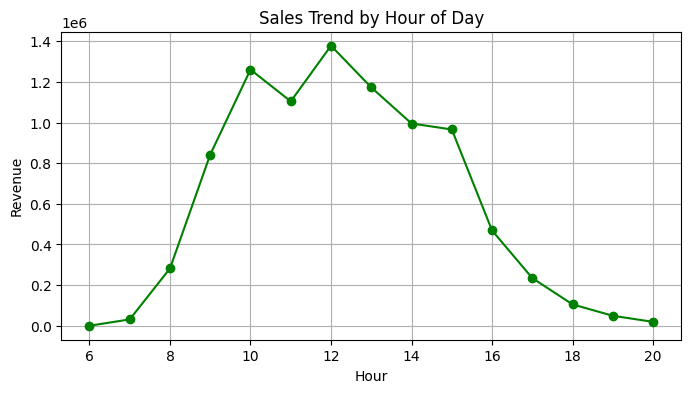

In [ ]:
hourly_sales = df.groupby('Hour')['TotalPrice'].sum()
plt.figure(figsize=(8,4))
hourly_sales.plot(kind='line', marker='o', color='green')
plt.title('Sales Trend by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()


**Top 10 Countries by Revenue**

Knowing which countries drive the most revenue allows businesses to tailor pricing by region — especially important for localized pricing strategies and market segmentation.

✅ This visualization supports region-specific price modeling, campaign targeting, and inventory decisions.



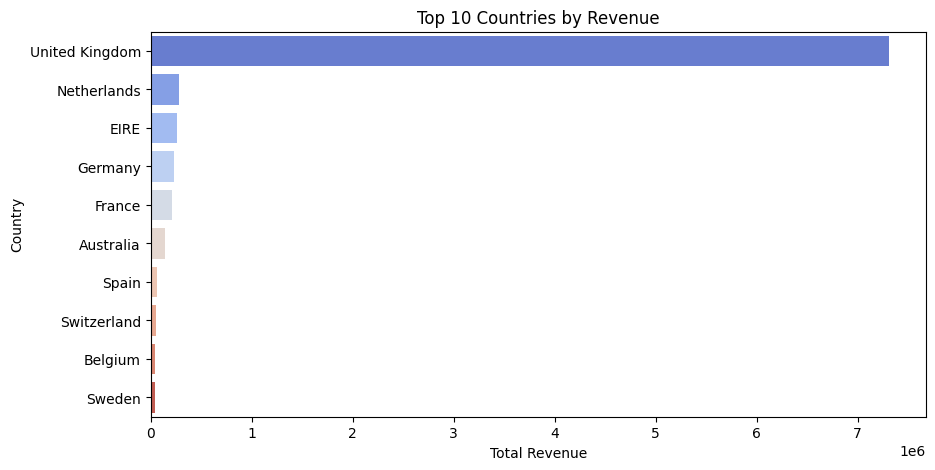

In [ ]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=country_sales.values, y=country_sales.index, palette='coolwarm')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Country')
plt.show()


**Visualize Feature Correlations**

Correlation analysis helps us understand how different variables relate to each other. This heatmap reveals:

🔹 Which features are positively or negatively related

🔹 Potential multicollinearity before modeling

🔹 How UnitPrice and TotalPrice behave with time-based and quantity features



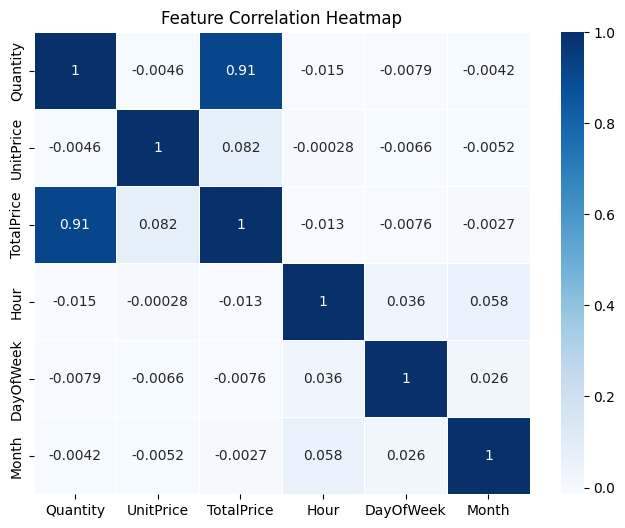

In [ ]:
corr_df = df[['Quantity', 'UnitPrice', 'TotalPrice', 'Hour', 'DayOfWeek', 'Month']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_df, annot=True, cmap='Blues', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()


**Distribution of Revenue per Transaction**

This plot shows the distribution of total revenue per invoice. It helps answer key business questions like:

What is the typical customer spending in a single transaction?

Are there outliers or high-value orders?

Should we implement tiered pricing or bundle offers?

✅ This visualization supports strategies like basket-based pricing, upselling, and minimum order thresholds.



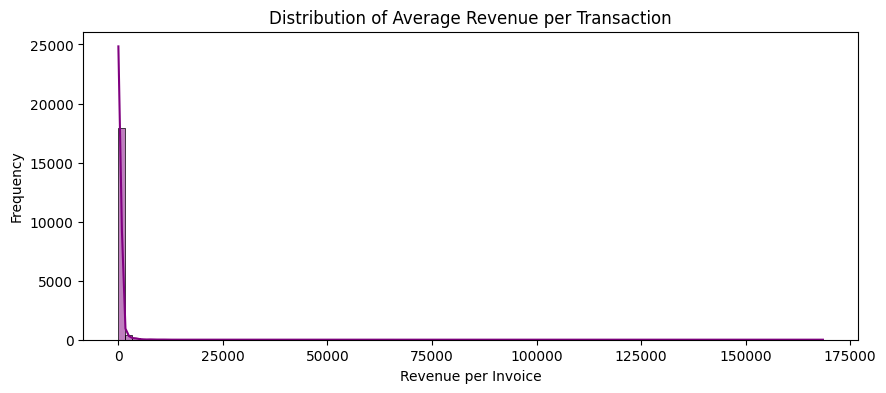

In [ ]:
invoice_avg = df.groupby('InvoiceNo')['TotalPrice'].sum()
plt.figure(figsize=(10,4))
sns.histplot(invoice_avg, bins=100, color='purple', kde=True)
plt.title('Distribution of Average Revenue per Transaction')
plt.xlabel('Revenue per Invoice')
plt.ylabel('Frequency')
plt.show()


**Boxplot of Product Prices (Under $100)**

To understand how most products are priced, we plot a boxplot of UnitPrice, excluding extreme outliers (prices above $100). This helps identify:

💰 Price concentration zones (e.g., most items under $10)

⚠️ Skewness in pricing distribution

🔍 Outliers that may need special pricing attention or investigation

✅ This chart guides strategies like price banding, low-margin product analysis, and value-based pricing.



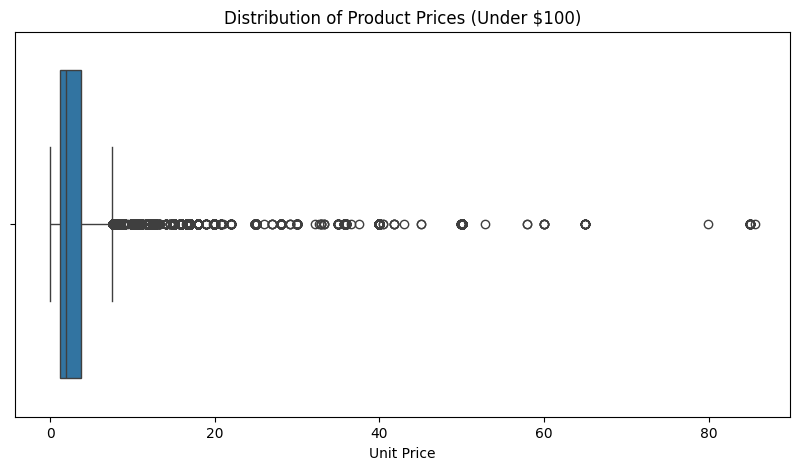

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x='UnitPrice', data=df[df['UnitPrice'] < 100])  # Filter out outliers
plt.title('Distribution of Product Prices (Under $100)')
plt.xlabel('Unit Price')
plt.show()


**Daily Revenue Trends Over Time**

This time-series plot shows daily revenue trends over the entire dataset period. It helps identify:

📆 Seasonal patterns or sales spikes

🚨 Anomalies or sudden drops in revenue

🎯 Ideal periods for price testing or promotions.

✅ This visualization supports time-aware pricing models, forecasting, and inventory alignment.




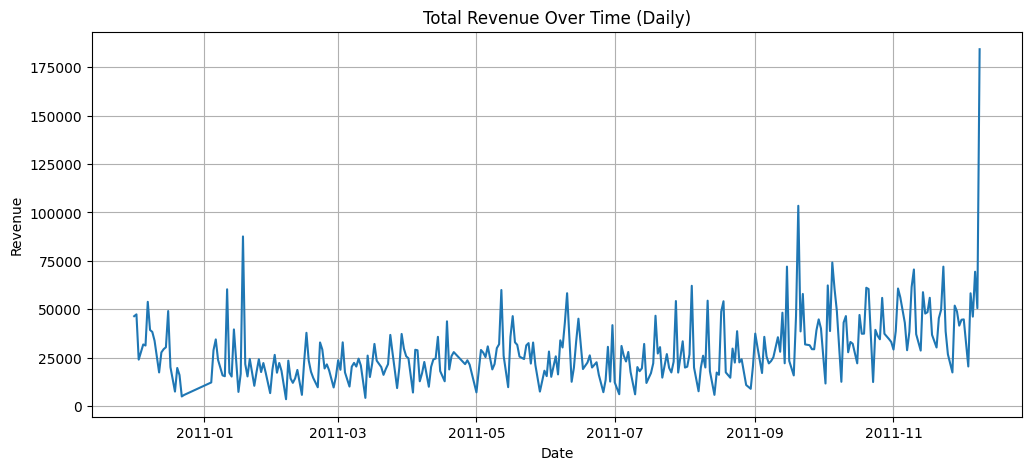

In [ ]:
daily_sales = df.groupby(df['InvoiceDate'].dt.date)['TotalPrice'].sum()

plt.figure(figsize=(12,5))
daily_sales.plot()
plt.title('Total Revenue Over Time (Daily)')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()


**Revenue Trends for Top 5 Products Over Time**

This multi-line time series chart shows how the top 5 revenue-generating products performed on a daily basis. It helps answer:

Which products have stable vs. fluctuating demand

When sales spikes occurred (launches, discounts, seasonality)

Where to apply product-level dynamic pricing


✅ This chart supports granular, per-product dynamic pricing models, ideal for maximizing revenue on fast-moving SKUs.

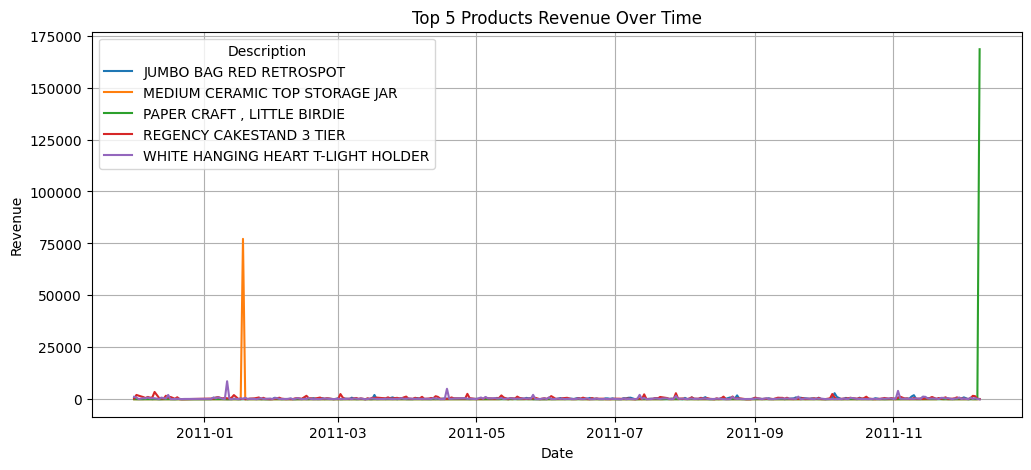

In [ ]:
top_items = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(5).index
top_items_df = df[df['Description'].isin(top_items)]
top_time = top_items_df.groupby([top_items_df['InvoiceDate'].dt.date, 'Description'])['TotalPrice'].sum().unstack().fillna(0)

top_time.plot(figsize=(12,5))
plt.title('Top 5 Products Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()


**Analyze Customer Shopping Frequency**

This histogram shows how frequently customers make purchases. It helps identify:

🛍️ One-time vs. repeat customers

🎯 Opportunities for loyalty programs or personalized pricing

📉 Price sensitivity patterns among infrequent buyers

✅ Frequent shoppers could be targeted with dynamic offers or volume-based discounts, while infrequent ones might need incentive pricing.

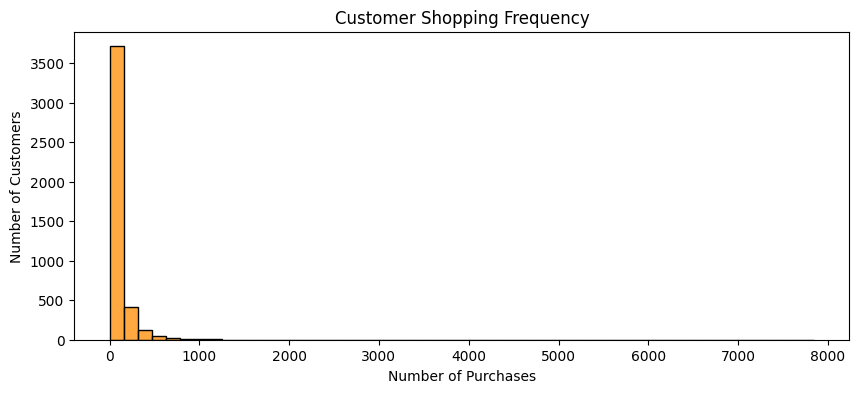

In [ ]:
cust_freq = df['CustomerID'].value_counts()
plt.figure(figsize=(10,4))
sns.histplot(cust_freq, bins=50, color='darkorange')
plt.title('Customer Shopping Frequency')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Customers')
plt.show()


**Sales Heatmap – Hour vs Day of Week**

This heatmap shows when customers are most active — combining hourly and daily patterns to identify hotspots for sales activity.

It helps answer:

 When do customers shop the most (e.g., Monday mornings or Friday evenings)?

 How can we use this to time price changes, flash sales, or surge pricing?

 ✅ This visualization supports hourly price adjustments and inventory alignment with peak demand periods.




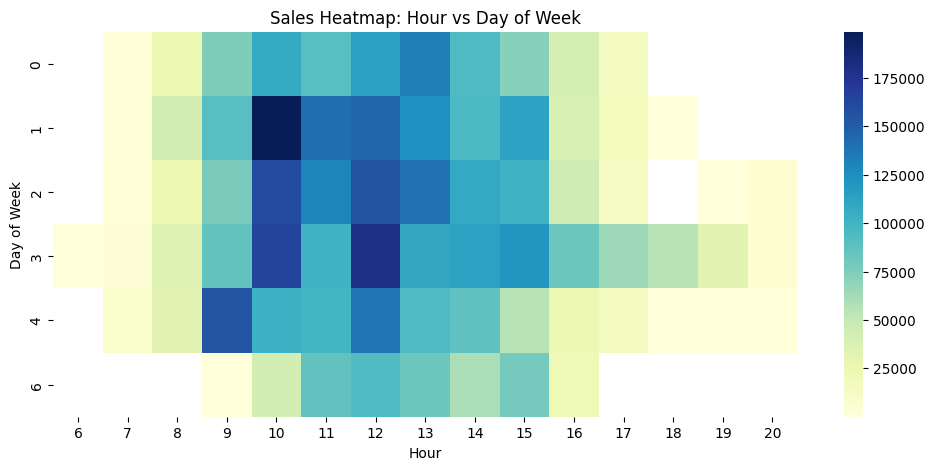

In [ ]:
pivot_table = df.pivot_table(values='Quantity', index='DayOfWeek', columns='Hour', aggfunc='sum')

plt.figure(figsize=(12,5))
sns.heatmap(pivot_table, cmap='YlGnBu')
plt.title('Sales Heatmap: Hour vs Day of Week')
plt.xlabel('Hour')
plt.ylabel('Day of Week')
plt.show()


**Analyze Price Elasticity of Demand**

This scatter plot shows the relationship between a product’s average price and the total quantity sold. It serves as a visual proxy for price elasticity — how demand reacts to price changes.

Key insights this can reveal:

📌 Products with high demand at low price = price sensitive

💎 Products with stable demand at high price = inelastic, ideal for premium pricing

🎯 Identify SKUs for discounts vs. price increases

✅ This analysis helps tailor dynamic pricing rules based on product elasticity.



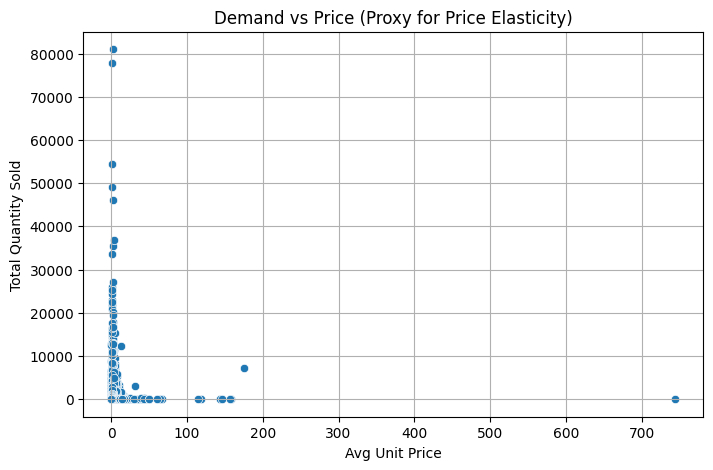

In [ ]:
# Correlation between price and quantity sold
elasticity_df = df.groupby('StockCode').agg({
    'Quantity': 'sum',
    'UnitPrice': 'mean'
}).reset_index()

plt.figure(figsize=(8,5))
sns.scatterplot(data=elasticity_df, x='UnitPrice', y='Quantity')
plt.title('Demand vs Price (Proxy for Price Elasticity)')
plt.xlabel('Avg Unit Price')
plt.ylabel('Total Quantity Sold')
plt.grid(True)
plt.show()


**Analyze Product Lifecycle (Days Active on Market)**

Understanding how long a product has been active in the catalog can inform:

🆕 Launch pricing strategies for new products

📉 Discounting or clearance for aging SKUs

 Feature engineering based on product age for model training

This plot shows the distribution of days each product was active in the market.

✅ This helps integrate age-based dynamic pricing rules — like early-bird pricing or end-of-life discounts.

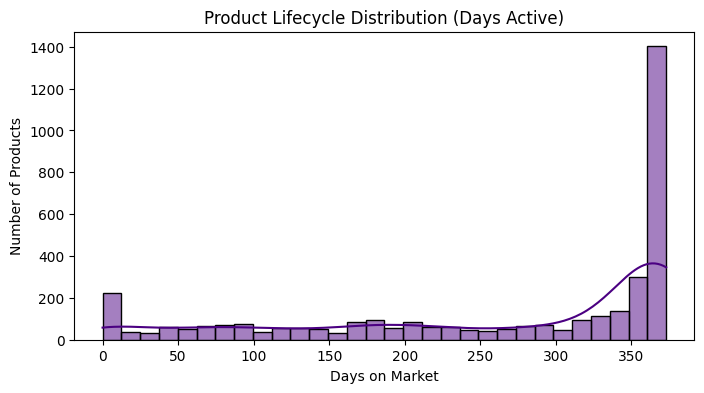

In [ ]:
product_age = df.groupby('StockCode')['InvoiceDate'].agg(['min', 'max'])
product_age['days_active'] = (product_age['max'] - product_age['min']).dt.days

plt.figure(figsize=(8,4))
sns.histplot(product_age['days_active'], bins=30, kde=True, color='indigo')
plt.title('Product Lifecycle Distribution (Days Active)')
plt.xlabel('Days on Market')
plt.ylabel('Number of Products')
plt.show()


**Pareto Analysis – Cumulative Revenue Contribution**

Using the Pareto principle, we analyze how many products contribute to 80% of total revenue. This helps:

🎯 Focus pricing models on high-impact SKUs

📦 Allocate inventory efficiently

💰 Apply premium or value-based pricing to top earners

✅ This analysis helps identify the critical few products that should be the main focus of dynamic pricing and promotional strategies.


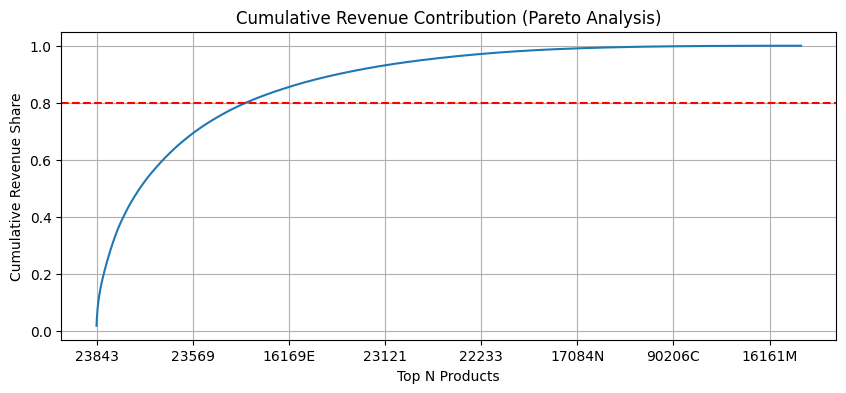

In [ ]:
revenue_by_product = df.groupby('StockCode')['TotalPrice'].sum().sort_values(ascending=False)
cumulative_share = revenue_by_product.cumsum() / revenue_by_product.sum()

plt.figure(figsize=(10,4))
cumulative_share.plot()
plt.axhline(y=0.8, color='r', linestyle='--')
plt.title('Cumulative Revenue Contribution (Pareto Analysis)')
plt.xlabel('Top N Products')
plt.ylabel('Cumulative Revenue Share')
plt.grid(True)
plt.show()


**Estimate Product Profitability**

To go beyond revenue and understand actual business value, we simulate cost prices and calculate estimated profits. This reveals:

💰 Which products deliver the highest profit margins

🧠 How profit compares with revenue (they’re not always aligned!)

🔄 Which products can bear discounts vs. deserve markups

✅ This enables profit-driven pricing models, ensuring you're not just boosting sales — you're optimizing margins.

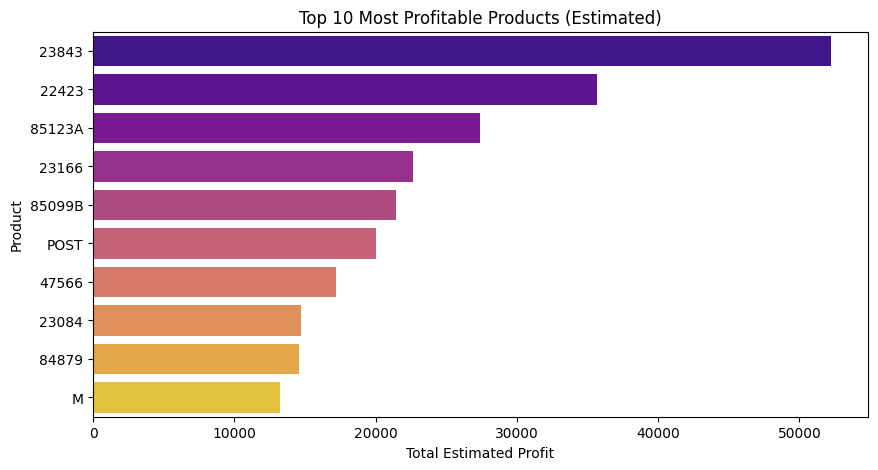

In [ ]:
# Simulated cost price (e.g., 60–90% of UnitPrice)
df['CostPrice'] = df['UnitPrice'] * np.random.uniform(0.6, 0.9, size=len(df))
df['ProfitPerUnit'] = df['UnitPrice'] - df['CostPrice']
df['ProfitTotal'] = df['ProfitPerUnit'] * df['Quantity']

profit_by_product = df.groupby('StockCode')['ProfitTotal'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=profit_by_product.values, y=profit_by_product.index, palette='plasma')
plt.title('Top 10 Most Profitable Products (Estimated)')
plt.xlabel('Total Estimated Profit')
plt.ylabel('Product')
plt.show()


**Prioritize Products for Dynamic Pricing Using Composite Scores**

To focus pricing strategies on the most important products, we create a composite score based on:

Revenue Score (normalized total revenue)

Demand Score (normalized total quantity sold)

We combine both using multiplication to find products that are both high revenue and high demand — the best candidates for intelligent pricing adjustments.

In [ ]:
# Normalize revenue and quantity
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
product_df[['Revenue_Score', 'Demand_Score']] = scaler.fit_transform(
    product_df[['Total_Revenue', 'Total_Quantity']]
)

# Composite score = Revenue * Demand
product_df['Pricing_Priority_Score'] = product_df['Revenue_Score'] * product_df['Demand_Score']

top_priority = product_df.sort_values('Pricing_Priority_Score', ascending=False).head(10)

top_priority[['StockCode', 'Pricing_Priority_Score']]


,StockCode,Pricing_Priority_Score
2329,23843,1.000000
1927,23166,0.464901
3343,85099B,0.288420
3349,85123A,0.271183
2602,84879,0.146628
1018,22197,0.134179
1218,22423,0.129593
1849,23084,0.102357
2406,47566,0.077144
1187,22386,0.055105


**Train a Baseline Linear Regression Model**

Before using complex models, we build a baseline using Linear Regression to predict optimal product prices. This helps:

🎯 Benchmark performance

 Interpret feature relationships (as it's a transparent model)

🔍 Detect overfitting when compared to non-linear models

✅ Linear models offer speed and interpretability, useful for pricing rules where transparency is needed (e.g., finance, retail approvals).


In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))


Linear Regression RMSE: 6.206483990522305


**Train XGBoost Model for Optimal Price Prediction**

To improve accuracy, we use XGBoost, a state-of-the-art ensemble model that:

 Handles non-linear feature relationships

 Performs well with outliers and missing values

 Often ranks high in real-world pricing prediction problems

 ✅ XGBoost is ideal for real-time, data-driven pricing systems, offering both speed and performance.

In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

print("XGBoost RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))


XGBoost RMSE: 1.091012885749163


**Train Gradient Boosting Regressor (GBR)**

We now use Gradient Boosting, a powerful ensemble method known for:

✅ Handling complex feature interactions

✅ Reducing overfitting compared to decision trees

✅ Often delivering strong performance with minimal tuning

✅ GBR is commonly used in e-commerce pricing systems, especially when interpretability is also important.



In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)

print("Gradient Boosting RMSE:", np.sqrt(mean_squared_error(y_test, gbr_pred)))


Gradient Boosting RMSE: 1.987668812399672


**Train LightGBM Model for Optimal Price Prediction**

LightGBM (Light Gradient Boosting Machine) is a fast, efficient model that:

 Trains faster and uses less memory than traditional GBDTs

 Handles large datasets and high-dimensional features very well

 This widely adopted in real-time pricing systems

 ✅ LightGBM is highly suitable for scalable and production-grade pricing models.

In [ ]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(n_estimators=100)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)

print("LightGBM RMSE:", np.sqrt(mean_squared_error(y_test, lgb_pred)))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000542 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 796
[LightGBM] [Info] Number of data points in the train set: 2932, number of used features: 6
[LightGBM] [Info] Start training from score 14.191040
LightGBM RMSE: 3.636472924427871


**Compare Model Performances (RMSE)**

To choose the best model, we compare the Root Mean Squared Error (RMSE) across all trained models:

✅ Lower RMSE means better price prediction accuracy

 This comparison helps in selecting the model to deploy for pricing recommendations

 ✅ This evaluation lets you justify model selection with transparency and credibility, which is key in real-world pricing systems.

In [ ]:
results = {
    "Model": ["Linear Regression", "Random Forest", "XGBoost", "Gradient Boosting"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, y_pred)),  # from RF earlier
        np.sqrt(mean_squared_error(y_test, xgb_pred)),
        np.sqrt(mean_squared_error(y_test, gbr_pred)),
    ]
}

results_df = pd.DataFrame(results)
results_df.sort_values(by="RMSE")


,Model,RMSE
2,XGBoost,1.091013
1,Random Forest,1.701280
3,Gradient Boosting,1.987669
0,Linear Regression,6.206484


**Model Explainability with SHAP (Shapley Values)**

To make your pricing model transparent and trustworthy, we use SHAP to explain the contribution of each feature to the predicted price.

 TreeExplainer is used for tree-based models (like Random Forest, XGBoost, etc.)

 The bar plot shows the average impact of each feature across the dataset

✅ This plot helps you understand which features influence pricing the most, boosting trust in your model from both business and data science stakeholders.


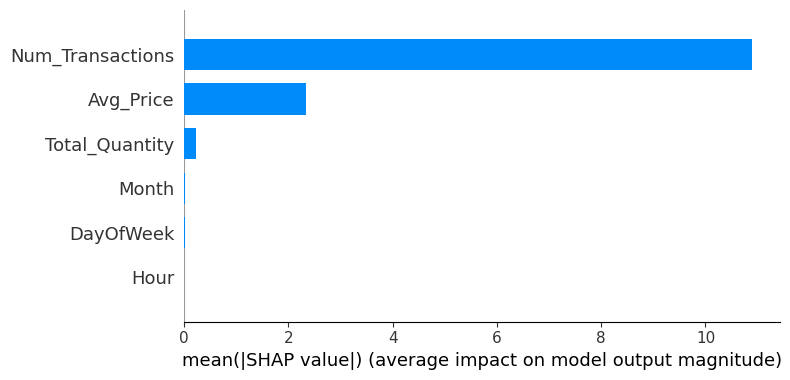

In [ ]:
import shap

# Use TreeExplainer for tree-based models like Random Forest
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, plot_type="bar")


In [ ]:
!pip install ipywidgets
from ipywidgets import interact, FloatSlider, IntSlider
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.0 MB/s eta 0:00:00


**Build a Real-Time Optimal Price Prediction Function**

This function allows you to simulate dynamic price recommendations based on product features:

 Takes inputs like average price, demand, and time info

 Uses the trained model to predict the optimal selling price

 Can be connected to a dashboard or pricing engine

 ✅ This is how you go from model development to product-ready inference — the final step in an end-to-end ML pipeline.

In [ ]:
def predict_price(avg_price, quantity, transactions, month, hour, day):
    input_data = np.array([[avg_price, quantity, transactions, month, hour, day]])
    prediction = model.predict(input_data)[0]
    print(f"💰 Predicted Optimal Price: ₹{prediction:.2f}")


**Visualize Dynamic Price Behavior — Quantity vs. Predicted Price**

To explore how pricing responds to changes in demand, we simulate and plot predictions across a range of quantity values, holding other inputs constant.

 Demonstrates how price adapts with quantity (e.g., bulk pricing, scarcity pricing)

 Helps business users visualize model sensitivity

 Encourages interactive experimentation and insight discovery

 ✅ This visualization adds depth, interactivity, and interpretability — turning  notebook into an AI-powered pricing simulator.

In [ ]:
import matplotlib.pyplot as plt

def plot_price_vs_quantity(avg_price, transactions, month, hour, day):
    quantities = list(range(0, 1000, 50))
    prices = []
    for q in quantities:
        input_data = np.array([[avg_price, q, transactions, month, hour, day]])
        prices.append(model.predict(input_data)[0])

    plt.figure(figsize=(8,4))
    plt.plot(quantities, prices, marker='o')
    plt.title("Predicted Price vs Quantity Sold")
    plt.xlabel("Quantity")
    plt.ylabel("Predicted Price (₹)")
    plt.grid(True)
    plt.show()

interact(
    plot_price_vs_quantity,
    avg_price=FloatSlider(min=1, max=100, value=20, step=1),
    transactions=IntSlider(min=0, max=500, value=50, step=10),
    month=IntSlider(min=1, max=12, value=6),
    hour=IntSlider(min=0, max=23, value=12),
    day=IntSlider(min=0, max=6, value=3)
)


interactive(children=(FloatSlider(value=20.0, description='avg_price', min=1.0, step=1.0), IntSlider(value=50,…

<function __main__.plot_price_vs_quantity(avg_price, transactions, month, hour, day)>

**Time-Aware Pricing — Heatmap of Predicted Prices by Hour and Day**

This heatmap helps visualize how predicted optimal prices fluctuate throughout the week and across the day:

 Shows temporal demand influence (e.g., weekends vs. weekdays)

 Detects peak hours where dynamic pricing can increase margins

 Helps teams decide when to apply discounts or markups

 ✅ This shows your model supports temporal dynamic pricing, critical for industries like e-commerce, travel, and food delivery.

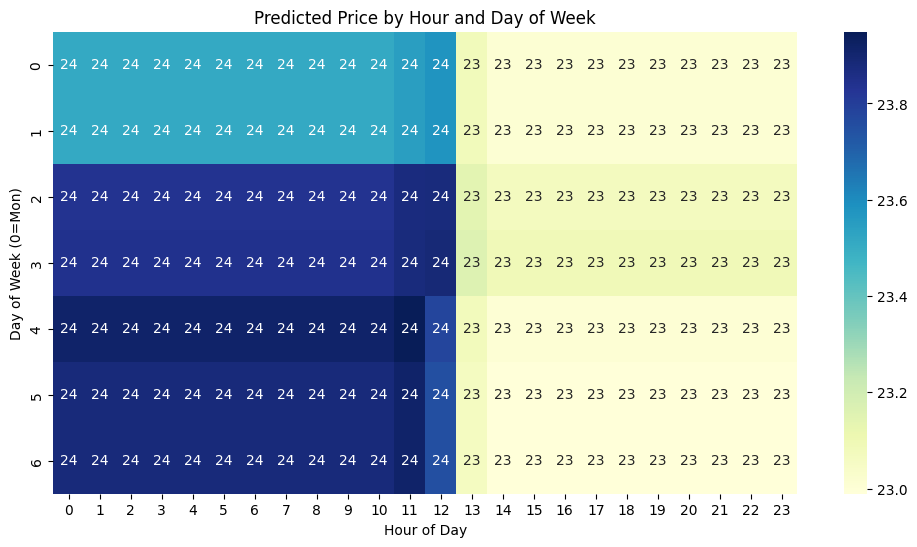

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np

# Create grid of all hour and day combinations
hours = list(range(24))
days = list(range(7))
price_matrix = []

for d in days:
    row = []
    for h in hours:
        input_data = np.array([[20, 300, 100, 6, h, d]])  # Keep other inputs fixed
        pred = model.predict(input_data)[0]
        row.append(pred)
    price_matrix.append(row)

# Convert to DataFrame
price_df = pd.DataFrame(price_matrix, index=days, columns=hours)

plt.figure(figsize=(12,6))
sns.heatmap(price_df, cmap="YlGnBu", annot=True, fmt=".0f")
plt.title("Predicted Price by Hour and Day of Week")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week (0=Mon)")
plt.show()
